#### _This Notebook if for intense exercise workout on Core Data science skill,Hotel Booking dataset is used here._
##### _This dataset records hotel booking information for two hotels (Resort & City Hotel). Each row = one booking._

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 
import plotly.express as px

#### _Loading Hotel Booking report dataset_

In [2]:
df=pd.read_csv("C:/Users/ASUS/Downloads/hotel_bookings.csv/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

#####  Q1. Basic Shape & Types
       Find:
       Number of rows and columns
       Data types of each column
       Which columns are numeric vs categorical

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

##### Q2. Cancellation Rate (Overall)
      Find:
      Overall percentage of bookings that were canceled.

In [5]:
df['is_canceled'].mean()*100

np.float64(37.041628277075134)

##### Q3. Cancellation Rate by Hotel Type
      Find:
      Cancellation percentage for City Hotel vs Resort Hotel.
      Which hotel type has a higher cancellation rate?

In [6]:
grouped=df.groupby('hotel')['is_canceled'].agg("mean")
print(grouped*100)

hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64


In [7]:
pd.crosstab(df['hotel'], df['is_canceled'], normalize='index') * 100

is_canceled,0,1
hotel,,
City Hotel,58.273037,41.726963
Resort Hotel,72.236645,27.763355


##### Q4. Distribution of Lead Time
      Find:
      Summary statistics of lead_time (min, max, mean, median).
      Plot a histogram (or KDE) of lead_time.

In [8]:
print(df['lead_time'].median())
print(df['lead_time'].describe())

69.0
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64


###### So the basic stats of 'lead_time' column is here.
       Now we plot histogram for 'lead_time' - which shows that most of the booking were done on table (0 Time), and then decreases
       exponentially, with mean of the lead_time equals to 104(overall).
       when we group by 'hotel' , we find that mean lead_time of City Hostel (109) type was more than Resort Type hostel(92.67)

<Axes: xlabel='lead_time', ylabel='Count'>

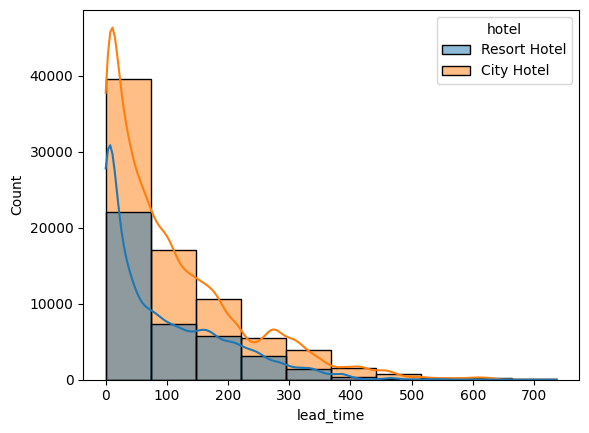

In [9]:
sns.histplot(df,x='lead_time',kde=True,bins=10,hue='hotel')

In [10]:
df['hotel'].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [11]:
df.groupby('hotel')['lead_time'].mean()

hotel
City Hotel      109.735724
Resort Hotel     92.675686
Name: lead_time, dtype: float64

##### Q5. Lead Time vs Cancellation (Simple Split)
     Find:
     Average lead_time for canceled vs non-canceled bookings.
     Which group tends to book earlier?

In [12]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

###### This shows that the most of the cancelled booking was booked long before arrival.

##### Q6. Top 5 Countries by Number of Bookings
      Find:
      The top 5 countries by booking count.
      What percentage of total bookings do these top 5 countries represent?

In [13]:
df['country'].value_counts(normalize=True).head()

country
PRT    0.408656
GBR    0.102008
FRA    0.087593
ESP    0.072059
DEU    0.061286
Name: proportion, dtype: float64

In [14]:
df['country'].value_counts(normalize=True).head().sum()*100

np.float64(73.16024961733193)

###### Hence, Leading Countries are Portugal(40.8%),Great Britain(10.2%),France(8.7%),Spain(7.2%) and Germany(6.1%), these top 5 collectively making 73.16% of booking.

##### Q7. Cancellation Rate by Customer Type
      Find:
      Cancellation rate for each customer_type.
      Which customer type is most likely to cancel?

In [15]:
df.groupby('customer_type')['is_canceled'].mean()*100

customer_type
Contract           30.961727
Group              10.225303
Transient          40.746320
Transient-Party    25.429868
Name: is_canceled, dtype: float64

###### Transient (staying for short period) type  of customer has most cancellation rate, followed by Contract and Transient-Party category.

##### Q8. ADR (Price) Comparison by Hotel Type
      Find:
      Mean and median adr for City Hotel vs Resort Hotel.
      Plot a boxplot of adr by hotel.

In [16]:
df.groupby('hotel')['adr'].agg(['mean','median','max'])

,mean,median,max
hotel,,,
City Hotel,105.304465,99.9,5400.0
Resort Hotel,94.952930,75.0,508.0


<Axes: xlabel='hotel', ylabel='adr'>

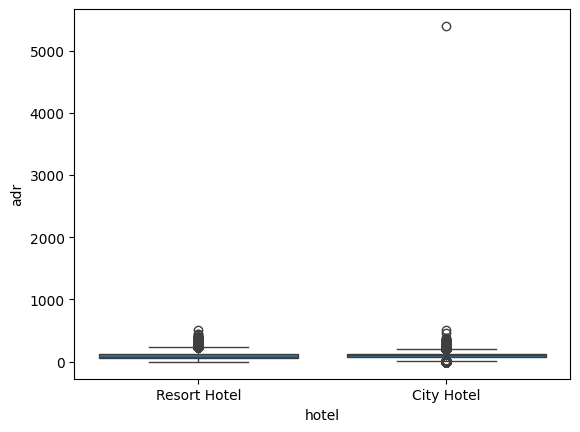

In [17]:
sns.boxplot(df,x='hotel',y='adr')

###### As from plotting box plot , we can clearly see that there is a clear outlier in City Hostel category, which may be due to wrong entry.This outlier is distorting box plot , so in next plot we will plot boxplot using quantile method to slice that outlier away.

,mean,median,max
hotel,,,
City Hotel,105.23262,99.9,451.5
Resort Hotel,94.95293,75.0,508.0


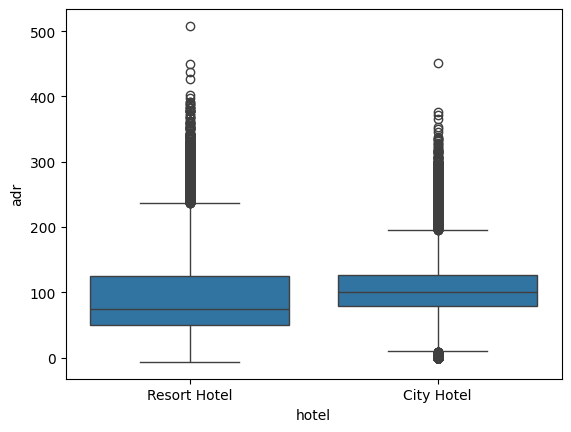

In [18]:
q999=df['adr'].quantile(0.99999)
sns.boxplot(df[df['adr']<=q999],x='hotel',y='adr')
df[df['adr']<=q999].groupby('hotel')['adr'].agg(['mean','median','max'])

###### As there is only one clear outlier in city hostel category , instead of removing or imputing using advanced method , we can just put its value as median adr of City hotel, but remember adr can be related to some other features like 'arrival_date_month'(season),'assigned_room_type' etc. we could also replace outlier value using these feature , but putting just median(City hotel) is for simplicity.

In [19]:
df.loc[df['adr']>5000,'adr']=99.9

<Axes: xlabel='hotel', ylabel='adr'>

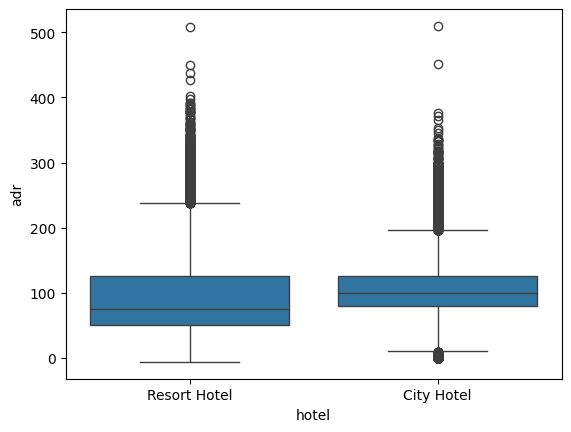

In [20]:
sns.boxplot(df,x='hotel',y='adr')

##### Q9. Repeat Guests vs First-Time Guests
    Find:
    Cancellation rate for is_repeated_guest = 1 vs 0.
    Do repeat guests cancel less?

In [21]:
pd.crosstab(df['is_repeated_guest'],df['is_canceled'],normalize='index')*100

is_canceled,0,1
is_repeated_guest,,
0,62.214916,37.785084
1,85.511811,14.488189


###### Yes,repeated guest often cancel less than first time guest. A/C to data, 37.78% of First time guest canceled the booking which is almost less than three times of cancellation rate of repeated guest i.e 14.48% only.

##### Q10. Special Requests & Cancellation
    Find:
    Average total_of_special_requests for canceled vs non-canceled bookings.
    Does higher engagement (more requests) associate with lower cancellation?

In [22]:
df.groupby('is_canceled')['total_of_special_requests'].agg('mean')*100

is_canceled
0    71.405955
1    32.882598
Name: total_of_special_requests, dtype: float64

###### Yes, ofcourse higher engagement (more requests) is associated with lower cancellation , people who often canceled the booking tends to made less special request. 

##### Q11. Cancellation Rate by Hotel × Customer Type
     Find:
     Cancellation rate for each combination of hotel and customer_type.
     Which customer type cancels the most within each hotel?

In [23]:
table=pd.pivot_table(data=df,index='hotel',columns='customer_type',values='is_canceled',aggfunc='mean')*100
print(table)

customer_type   Contract      Group  Transient  Transient-Party
hotel                                                          
City Hotel     48.043478   9.897611  45.616457        28.096694
Resort Hotel    8.840090  10.563380  31.169519        19.496855


In [24]:
df.groupby(['hotel','customer_type'])['is_canceled'].mean() * 100


hotel         customer_type  
City Hotel    Contract           48.043478
              Group               9.897611
              Transient          45.616457
              Transient-Party    28.096694
Resort Hotel  Contract            8.840090
              Group              10.563380
              Transient          31.169519
              Transient-Party    19.496855
Name: is_canceled, dtype: float64

###### For City hotel category,Contract(48%) and Transient(45.6%) type of customer are the one which canceled the most followed by Transient-party.

##### Q12. Seasonality of Cancellations (Month × Hotel)
      Find:
      Cancellation rate by arrival_date_month for each hotel.
      Plot a heatmap of Month × Hotel with cancellation rate as color.

In [25]:
table2=pd.pivot_table(data=df,index='hotel',columns='arrival_date_month',values='is_canceled',aggfunc='mean')
print(table2)

arrival_date_month     April    August  December  February   January  \
hotel                                                                  
City Hotel          0.463235  0.400980  0.421104  0.382880  0.396681   
Resort Hotel        0.293433  0.334491  0.238293  0.256204  0.148199   

arrival_date_month      July      June     March       May  November  \
hotel                                                                  
City Hotel          0.408754  0.446922  0.369464  0.443756  0.381226   
Resort Hotel        0.314017  0.330706  0.228717  0.287721  0.189167   

arrival_date_month   October  September  
hotel                                    
City Hotel          0.429717   0.420270  
Resort Hotel        0.275105   0.323681  


<Axes: xlabel='arrival_date_month', ylabel='hotel'>

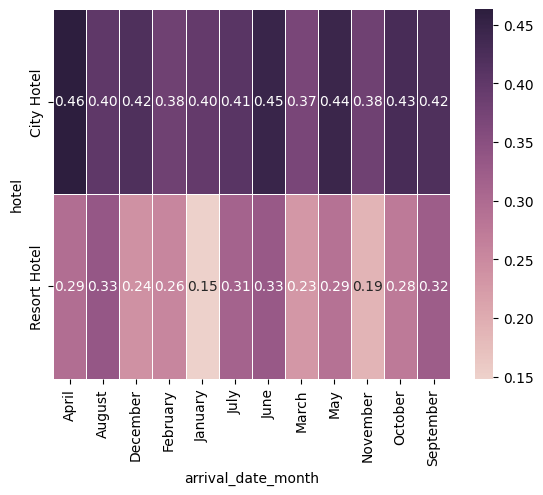

In [26]:
sns.heatmap(table2,annot=True,fmt=".2f",linewidth=.5,cmap=sns.cubehelix_palette(as_cmap=True))

##### Q13. Lead Time Buckets vs Cancellation
    Create lead time buckets: 0–7 days, 8–30, 31–90, 90+
    Find:
    Cancellation rate for each lead-time bucket.
    Which bucket has the highest cancellation rate?

In [27]:
bins=[-1,7,30,90,df['lead_time'].max()]
labels=['0-7','8-30','31-90','90+']
df['bucket_lead_time']=pd.cut(df['lead_time'],bins=bins,labels=labels)
print(df['bucket_lead_time'])

0           90+
1           90+
2           0-7
3          8-30
4          8-30
          ...  
119385     8-30
119386      90+
119387    31-90
119388      90+
119389      90+
Name: bucket_lead_time, Length: 119390, dtype: category
Categories (4, object): ['0-7' < '8-30' < '31-90' < '90+']


In [28]:
df.groupby('bucket_lead_time',observed=False)['is_canceled'].mean()*100

bucket_lead_time
0-7       9.632331
8-30     27.863924
31-90    37.698372
90+      50.650290
Name: is_canceled, dtype: float64

###### From the table ,it can be clearly seen that bucket of larger lead time often tends to have higher cancellation , so the bucket of '90+' have higher cancellation rate followed by bucket 0f '31-90' and '8-30'.

##### Q14. Market Segment × Distribution Channel (Counts + Cancellation)
     Find:
     A table of counts for each market_segment × distribution_channel.
     For each combination, compute cancellation rate.
     Goal: Multivariate slicing and normalization.

In [29]:
pd.crosstab(df['distribution_channel'],df['market_segment'])

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
distribution_channel,,,,,,,,
Corporate,227,89,4788,90,1228,212,43,0
Direct,0,576,172,12276,1472,16,133,0
GDS,0,0,0,1,0,45,147,0
TA/TO,10,78,335,237,17111,23946,56153,0
Undefined,0,0,0,2,0,0,1,2


In [30]:
pd.crosstab([df['distribution_channel'],df['market_segment']],df['is_canceled'],normalize=True)*100

is_canceled                                  0          1
distribution_channel market_segment                      
Corporate            Aviation         0.147416   0.042717
                     Complementary    0.057794   0.016752
                     Corporate        3.274981   0.735405
                     Direct           0.067007   0.008376
                     Groups           0.695201   0.333361
                     Offline TA/TO    0.091297   0.086272
                     Online TA        0.024290   0.011726
Direct               Complementary    0.423821   0.058631
                     Corporate        0.128151   0.015914
                     Direct           8.679956   1.602312
                     Groups           0.778122   0.454812
                     Offline TA/TO    0.010889   0.002513
                     Online TA        0.103861   0.007538
GDS                  Direct           0.000838   0.000000
                     Offline TA/TO    0.030991   0.006701
                     Online TA        0.098836   0.024290
TA/TO                Aviation         0.007538   0.000838
                     Complementary    0.059469   0.005863
                     Corporate        0.201022   0.079571
                     Direct           0.190133   0.008376
                     Groups           4.987855   9.344166
                     Offline TA/TO   13.191222   6.865734
                     Online TA       29.706843  17.326409
Undefined            Direct           0.000838   0.000838
                     Online TA        0.000000   0.000838
                     Undefined        0.000000   0.001675

###### Using crosstab function, it works but when you pass a list of two variables into the rows (index), Pandas creates a Multi-Index. It’s mathematically correct, but for human eyes, it’s a disaster to read and its also complex to plot heatmap from it.So we will use pivot table to make it visually pleasing and less complex to plot heatmap.

In [31]:
pivot_ms_dc = df.pivot_table(index='market_segment', 
                          columns='distribution_channel', 
                          values='is_canceled', 
                          aggfunc='mean') * 100

print(pivot_ms_dc)

distribution_channel  Corporate     Direct        GDS      TA/TO  Undefined
market_segment                                                             
Aviation              22.466960        NaN        NaN  10.000000        NaN
Complementary         22.471910  12.152778        NaN   8.974359        NaN
Corporate             18.337510  11.046512        NaN  28.358209        NaN
Direct                11.111111  15.583252   0.000000   4.219409       50.0
Groups                32.410423  36.888587        NaN  65.197826        NaN
Offline TA/TO         48.584906  18.750000  17.777778  34.231187        NaN
Online TA             32.558140   6.766917  19.727891  36.838637      100.0
Undefined                   NaN        NaN        NaN        NaN      100.0


<Axes: xlabel='distribution_channel', ylabel='market_segment'>

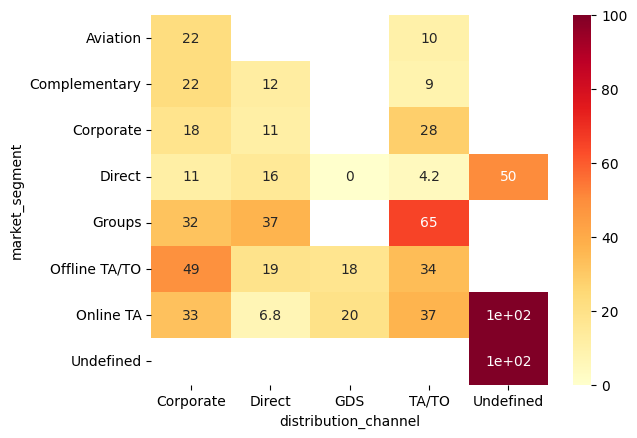

In [32]:
sns.heatmap(pivot_ms_dc,annot=True,cmap='YlOrRd')

##### Q15. ADR by Hotel × Deposit Type (Mean & Median + Heatmap)
    Find:
    Mean and median ADR for each hotel × deposit_type.
    Plot a heatmap of mean ADR across Hotel × Deposit Type.

In [33]:

pivot_htl_dst=pd.pivot_table(df,index='hotel',columns='deposit_type',values='adr',aggfunc=['mean','median'])
pivot_htl_dst

mean                            median             \
deposit_type  No Deposit Non Refund  Refundable No Deposit Non Refund   
hotel                                                                   
City Hotel    107.658387  92.723426  114.977500      101.5       90.0   
Resort Hotel   96.335715  66.224532   70.749507       76.5       70.0   

                         
deposit_type Refundable  
hotel                    
City Hotel        100.0  
Resort Hotel       66.0

<Axes: xlabel='None-deposit_type', ylabel='hotel'>

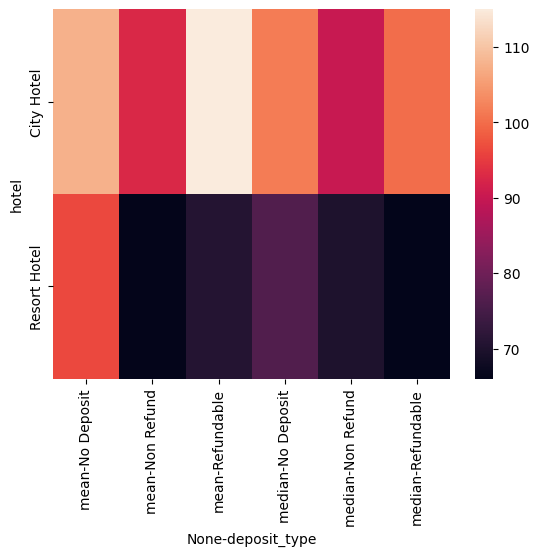

In [34]:
sns.heatmap(pivot_htl_dst)

##### Q16. Special Requests × Cancellation × Hotel (3 Variables)
    Find:
    Average total_of_special_requests for:
    Canceled vs Not Canceled
    Separately for City Hotel and Resort Hotel

In [35]:
df.groupby(['hotel','is_canceled'])['total_of_special_requests'].mean()

hotel         is_canceled
City Hotel    0              0.741088
              1              0.275754
Resort Hotel  0              0.670883
              1              0.486783
Name: total_of_special_requests, dtype: float64

##### Q17. Length of Stay vs Cancellation (Derived Feature)
    Create:
    total_stay_nights = stays_in_weekend_nights + stays_in_week_nights
    Find:
    Cancellation rate by binned total stay (e.g., 1–2, 3–5, 6+ nights).
    Does longer stay associate with more or less cancellation?

In [36]:
df['total_stay_nights']=df['stays_in_weekend_nights']+df['stays_in_week_nights']
bins=[-1,2,5,df['total_stay_nights'].max()]
labels=['1-2','3-5','7+']
df['binned_nights']=pd.cut(df['total_stay_nights'],bins=bins,labels=labels)
df.groupby('binned_nights',observed=False)['is_canceled'].mean()*100

binned_nights
1-2    35.378104
3-5    38.994698
7+     35.922112
Name: is_canceled, dtype: float64

<Axes: xlabel='total_stay_nights', ylabel='Count'>

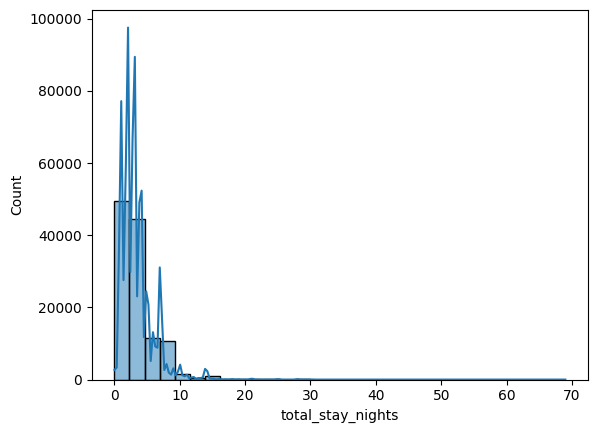

In [37]:
sns.histplot(df,x='total_stay_nights',bins=30,kde=True)

##### Q18. Simpson’s Paradox Check (Month × Hotel × Cancellation)
    Find:
    Overall cancellation rate by arrival_date_month.
    Then, within each hotel, compute monthly cancellation rates.
    Insight to check:
    Does the overall monthly cancellation trend weaken or change direction when you split by hotel type?

###### What Simpson’s Paradox Actually Is (Not Just “It Changes When You Split”)

    Simpson’s Paradox is not merely:
    “The numbers change when I stratify.” That happens all the time and is expected.
    Simpson’s Paradox is specifically:
    A trend seen in the aggregated data reverses or disappears when you split by a confounding variable.
    So we’re checking for something much more specific than:

    “City > Resort in cancellation” (that’s obvious)

    We’re checking whether:
    The direction or shape of the monthly trend (e.g., increasing vs decreasing, peak months, seasonality pattern)
    changes when you condition on hotel type.

In [38]:
df.groupby('arrival_date_month')['is_canceled'].mean().sort_values(ascending=False)*100

arrival_date_month
June         41.457172
April        40.797186
May          39.665847
September    39.170156
October      38.046595
August       37.753117
July         37.453598
December     34.970501
February     33.415964
March        32.152338
November     31.233441
January      30.477315
Name: is_canceled, dtype: float64

###### This above analysis gives a single curve over months:    Jan -> Feb -> Mar -> … -> Dec

    You might observe:
    Summer months have higher cancellation Or winter months dip Or a peak around August, etc.
    This is the aggregate seasonal pattern.

In [39]:
df.groupby(['hotel','arrival_date_month'])['is_canceled'].mean().sort_values(ascending=False)*100

hotel         arrival_date_month
City Hotel    April                 46.323529
              June                  44.692171
              May                   44.375607
              October               42.971729
              December              42.110358
              September             42.027027
              July                  40.875371
              August                40.097963
              January               39.668094
              February              38.288016
              November              38.122561
              March                 36.946423
Resort Hotel  August                33.449121
              June                  33.070608
              September             32.368082
              July                  31.401706
              April                 29.343308
              May                   28.772127
              October               27.510549
              February              25.620367
              December              23.829305
 

######     Now you have two curves:
    One curve for City Hotel over months
    One curve for Resort Hotel over months
    The question is:
    Do these two curves have the same shape as the overall curve?
    Not “are their levels different?” But:

    Do the peaks and troughs align?
    Does the direction of change match?
    For example:
    Overall cancellations rise from May to August
    But within Resort Hotel, cancellations might actually fall in that perio The overall rise could be driven by City Hotel dominating volume in those      months

    That’s the Simpson’s paradox check.

##### Q19. Price Sensitivity by Segment (ADR × Market Segment × Cancellation)
    Find:
    Mean and median ADR for canceled vs non-canceled bookings within each market_segment.
    Insight to check:
    Is the ADR–cancellation relationship consistent across segments, or does it differ by segment (interaction effect)?

In [40]:
df.groupby(['market_segment','is_canceled'])['adr'].agg(['mean','median'])

mean  median
market_segment is_canceled                    
Aviation       0             99.482054   95.00
               1            102.490385  106.75
Complementary  0              3.078545    0.00
               1              1.606495    0.00
Corporate      0             67.105399   65.00
               1             79.134194   79.00
Direct         0            113.875200  103.68
               1            124.108454  114.00
Groups         0             77.124541   72.00
               1             80.981161   70.00
Offline TA/TO  0             83.421750   80.75
               1             94.245239   90.00
Online TA      0            113.863099  107.10
               1            122.942238  116.10
Undefined      1             15.000000   15.00

##### Q20. Lead Time × Deposit Type Interaction
    Using your lead_time_bucket, Find:
    Cancellation rate by lead_time_bucket and deposit_type.

    Insight to check:
    Do non-refundable deposits reduce cancellations more strongly for long lead times than for short lead times?

In [41]:
df.groupby(['deposit_type','bucket_lead_time'],observed=False)['is_canceled'].mean()*100

deposit_type  bucket_lead_time
No Deposit    0-7                  9.164585
              8-30                26.044039
              31-90               32.189838
              90+                 36.400051
Non Refund    0-7                 85.123967
              8-30                96.558704
              31-90               99.792186
              90+                 99.541760
Refundable    0-7                 16.666667
              8-30                14.285714
              31-90               50.000000
              90+                 22.500000
Name: is_canceled, dtype: float64

###### “Non Refund” deposit type does NOT mean the booking cannot be canceled. It means: If the customer cancels, they lose the deposit (money).
    So we may think that the 'Refundable' type deposit would have less cancellation rate, but its revrse here. Non-Refundable type deposit have the highest cancellation rate here, This can be due to multiple reason :-
    Reason 1 : “Non Refund” bookings are mostly system/agent-driven reservations that are later canceled in bulk.
    Reason 2 : Class Imbalance & Small Sample Sizes.The “Refundable” category is usually tiny in this dataset.So a few cancellations can swing percentages wildly
    Reason 3 : Many risky bookings (long lead time, price-sensitive, group blocks) are offered as non-refundable deals.

    For confirmation,we will sanity check,count the cancellation and deposit type to check wether its class imbalance or Tiny dataset for Refundable type. 

In [42]:
pd.crosstab([df['bucket_lead_time'], df['deposit_type']], df['is_canceled'])

is_canceled                        0      1
bucket_lead_time deposit_type              
0-7              No Deposit    17821   1798
                 Non Refund       18    103
                 Refundable        5      1
8-30             No Deposit    13636   4802
                 Non Refund       17    477
                 Refundable       24      4
31-90            No Deposit    18403   8736
                 Non Refund        5   2401
                 Refundable        4      4
90+              No Deposit    25087  14358
                 Non Refund       53  11513
                 Refundable       93     27

In [43]:
pd.crosstab(df['bucket_lead_time'], df['deposit_type'])


deposit_type,No Deposit,Non Refund,Refundable
bucket_lead_time,,,
0-7,19619,121,6
8-30,18438,494,28
31-90,27139,2406,8
90+,39445,11566,120


###### From Sanity checks, its clarified that, there are 14587 Refundable type of deposit case out of which 14494 are canceled. So the aggregation we saw earlier was real, it shows that “Non Refund” bookings are mostly system/agent-driven reservations that are later canceled in bulk.

##### Q21. Confounding: Customer Type vs Cancellation, Controlled by Hotel
    Find:
    Overall cancellation rate by customer_type.
    Then, within each hotel, compute cancellation rate by customer_type.
    Insight to check:
    Does the ranking of customer types by cancellation change when you control for hotel type?

In [44]:
df.groupby('customer_type')['is_canceled'].mean()*100

customer_type
Contract           30.961727
Group              10.225303
Transient          40.746320
Transient-Party    25.429868
Name: is_canceled, dtype: float64

In [45]:
df.groupby(['hotel','customer_type'])['is_canceled'].mean()*100

hotel         customer_type  
City Hotel    Contract           48.043478
              Group               9.897611
              Transient          45.616457
              Transient-Party    28.096694
Resort Hotel  Contract            8.840090
              Group              10.563380
              Transient          31.169519
              Transient-Party    19.496855
Name: is_canceled, dtype: float64

In [46]:
pd.crosstab([df['hotel'],df['customer_type']],df['is_canceled'])

is_canceled                       0      1
hotel        customer_type                
City Hotel   Contract          1195   1105
             Group              264     29
             Transient        32306  27098
             Transient-Party  12463   4870
Resort Hotel Contract          1619    157
             Group              254     30
             Transient        20793   9416
             Transient-Party   6272   1519

Text(0.5, 1.0, 'The Confounding Flip: Contract Customers')

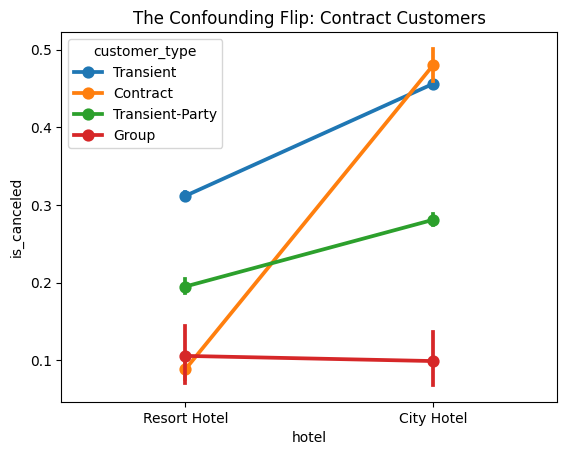

In [47]:
sns.pointplot(data=df, x='hotel', y='is_canceled', hue='customer_type')
plt.title('The Confounding Flip: Contract Customers')

###### Confounding / Simpson Paradox
    From the analysis, its clearly see that its confounding that Contract customer type of city hotel tends to have highest cancellation rate while for     Resort hotel type - they tends to have least cancellation rate.

    The "Corporate Trap" (City Hotel + Contract) :-
    City hotels are usually business hubs. A "Contract" customer here is often a company booking a block of rooms for a fixed period (e.g., for a 3-        month consulting project or airline crews).
    These contracts often have "Negotiated Rates" with very flexible cancellation policies. Since the company isn't paying out of pocket (it's a            corporate expense), they are much more likely to cancel or move dates at the last minute if the business meeting changes.

    The "Vacation Commitment" (Resort Hotel + Contract) :-
    A "Contract" at a Resort hotel is a completely different animal. This often refers to All-Inclusive Packages, Time-Shares, or Long-Term Holiday Let     agreements.

    Resort contracts are often tied to travel agencies or tour operators. These are "guaranteed" bookings where the agency pays the hotel regardless,       so the recorded "cancellation" rate stays near zero. 

##### Q22. Robust Price Summary by Season (Median vs Mean ADR)
    Find:
    Mean and median ADR by arrival_date_month and hotel.
    Insight to check: In which months does mean ADR diverge strongly from median ADR (hint: outliers / skew)?

In [48]:
df.groupby(['hotel','arrival_date_month'])['adr'].agg(['mean','median'])

mean   median
hotel        arrival_date_month                     
City Hotel   April               111.251838  105.000
             August              114.680455  109.000
             December             88.826307   85.000
             February             85.088278   80.000
             January              82.628986   80.000
             July                110.734292  107.100
             June                119.074341  117.370
             March                91.822413   88.000
             May                 121.638560  120.000
             November             88.069601   85.000
             October              99.974498   99.870
             September           110.004661  107.000
Resort Hotel April                77.849496   75.000
             August              186.790574  188.420
             December             68.984230   57.865
             February             55.171930   51.000
             January              49.461883   47.600
             July                155.181299  152.500
             June                110.444749  105.000
             March                57.520147   55.600
             May                  78.758134   73.000
             November             48.273993   45.000
             October              62.097617   58.000
             September            93.252030   86.000

Text(0.5, 1.0, 'City Hotel: Mean vs Median ADR (Spot the Gap!)')

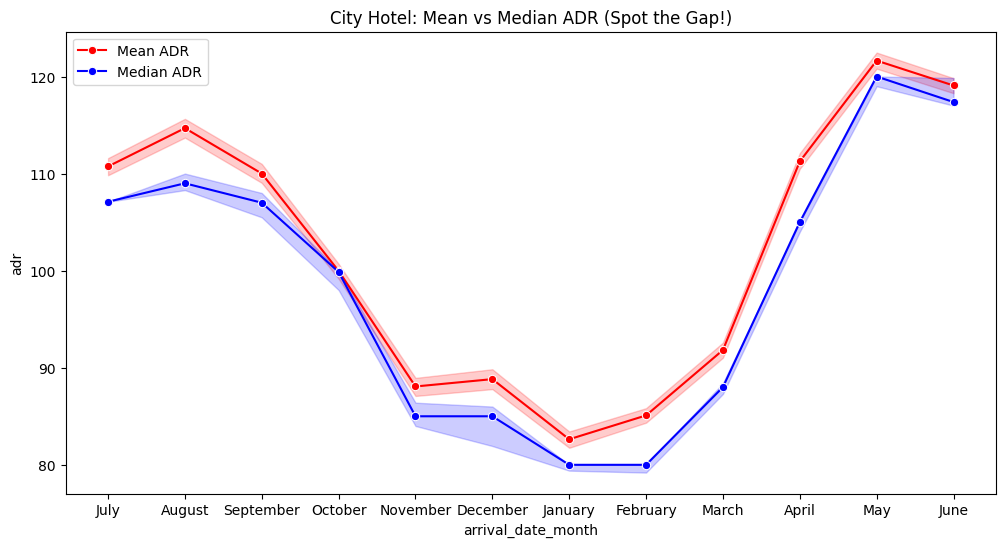

In [49]:
resort_df = df[df['hotel'] == 'City Hotel']

plt.figure(figsize=(12,6))
sns.lineplot(data=resort_df, x='arrival_date_month', y='adr', estimator='mean', label='Mean ADR', color='red', marker='o')
sns.lineplot(data=resort_df, x='arrival_date_month', y='adr', estimator='median', label='Median ADR', color='blue', marker='o')

plt.title('City Hotel: Mean vs Median ADR (Spot the Gap!)')


Text(0.5, 1.0, 'Resort Hotel: Mean vs Median ADR (Spot the Gap!)')

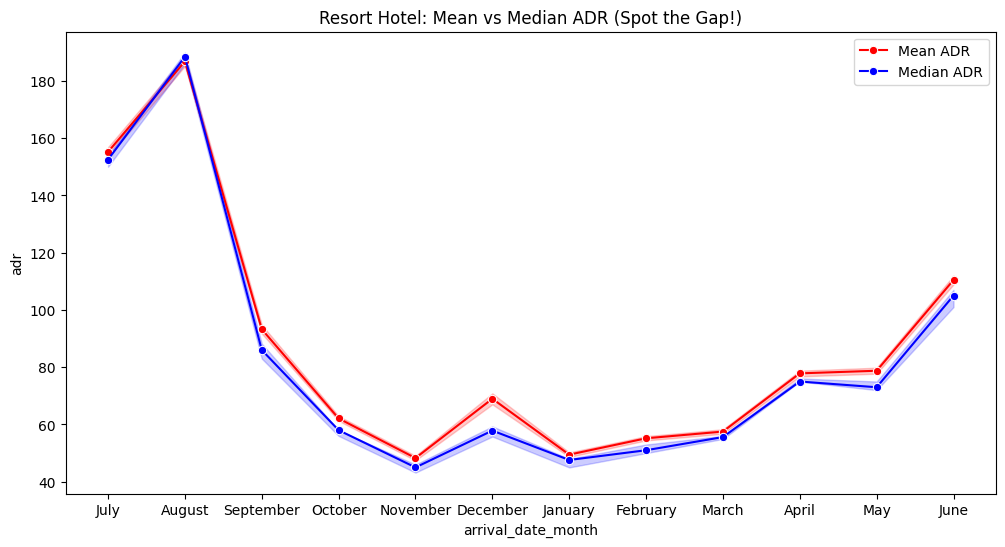

In [50]:
resort_df = df[df['hotel'] == 'Resort Hotel']

plt.figure(figsize=(12,6))
sns.lineplot(data=resort_df, x='arrival_date_month', y='adr', estimator='mean', label='Mean ADR', color='red', marker='o')
sns.lineplot(data=resort_df, x='arrival_date_month', y='adr', estimator='median', label='Median ADR', color='blue', marker='o')

plt.title('Resort Hotel: Mean vs Median ADR (Spot the Gap!)')


In [51]:
# 1. Calculate the table
res = df.groupby(['hotel','arrival_date_month'], observed=False)['adr'].agg(['mean','median'])

# 2. Calculate the "Divergence Score" (Percentage)
res['divergence'] = ((res['mean'] - res['median']) / res['median']) * 100

# 3. Sort to see the "Liars"
print(res.sort_values(by='divergence', ascending=False))

                                       mean   median  divergence
hotel        arrival_date_month                                 
Resort Hotel December             68.984230   57.865   19.215812
             September            93.252030   86.000    8.432593
             February             55.171930   51.000    8.180256
             May                  78.758134   73.000    7.887855
             November             48.273993   45.000    7.275539
             October              62.097617   58.000    7.064858
City Hotel   February             85.088278   80.000    6.360347
             April               111.251838  105.000    5.954132
             August              114.680455  109.000    5.211427
Resort Hotel June                110.444749  105.000    5.185475
City Hotel   December             88.826307   85.000    4.501537
             March                91.822413   88.000    4.343651
Resort Hotel January              49.461883   47.600    3.911519
             April       

<Axes: xlabel='arrival_date_month', ylabel='adr'>

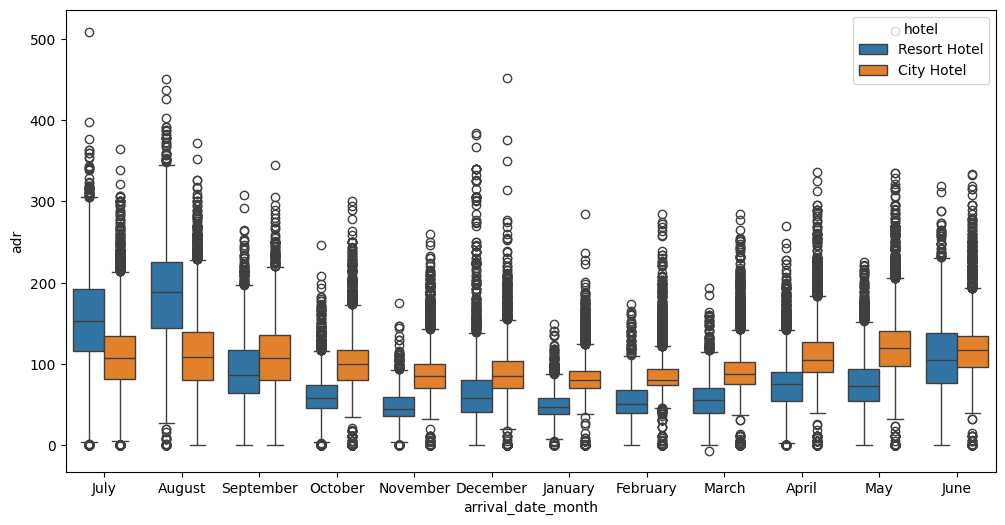

In [52]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='arrival_date_month', y='adr', hue='hotel')

##### Q23.High-Risk Profile Mining (Rule Discovery)
Define a “high-risk” profile such as:
1. Long lead time
2. Online TA segment
3. No deposit
4. First-time guest

Find:
Cancellation rate for this group vs overall cancellation rate.
Insight to check:
How much higher is the risk compared to the average customer?

In [53]:
high_risk=df[(df['lead_time']>df['lead_time'].median()) & 
             (df['market_segment']=='Online TA') &
             (df['deposit_type'] == 'No Deposit') & 
             (df['is_repeated_guest'] == 0)]
print(df['is_canceled'].mean()*100)
print(high_risk['is_canceled'].mean()*100)


37.041628277075134
46.43452050448163


So after defining broad filter on dataset, we got high risk profiles , which increased the cancellation rate from 37% to 46.4%.

##### Q24. Visual Multivariate Summary (Heatmap)
    Create:
    A heatmap of cancellation rate by hotel × customer_type
    A second heatmap by hotel × deposit_type
    Insight to check:
    Which combinations stand out as most risky?

<Axes: xlabel='None-customer_type', ylabel='hotel'>

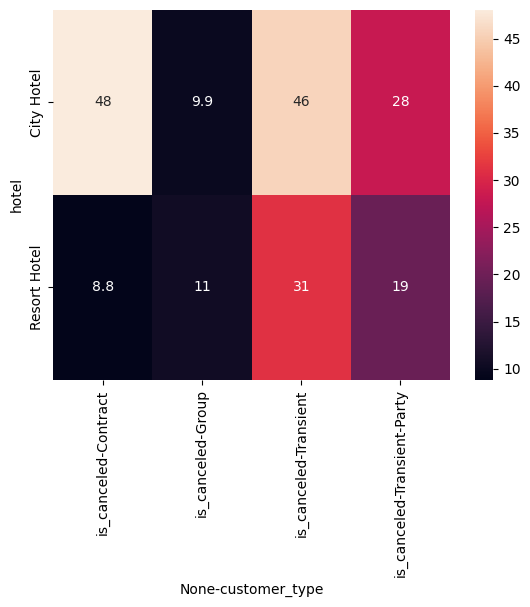

In [54]:
table3=df.pivot_table(index=df['hotel'],columns=['customer_type'],values=['is_canceled'],aggfunc='mean')*100
sns.heatmap(table3,annot=True)


For City hotel type,Contract and Transient type of customer is the most risky ones.For Resort Hotel,Transient customer type is the most risky one followed by Transient party.

<Axes: xlabel='None-deposit_type', ylabel='hotel'>

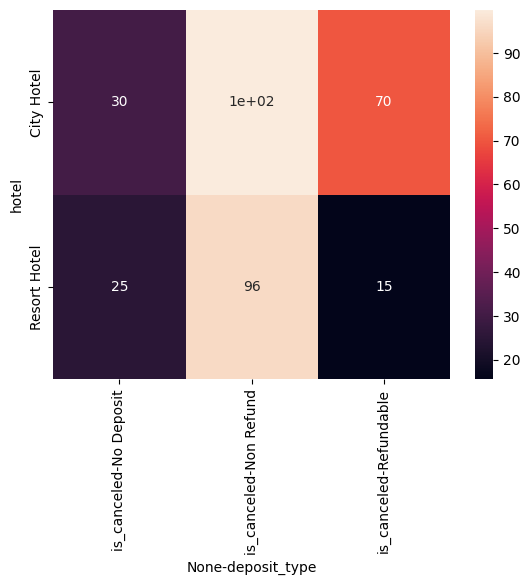

In [55]:
table4=df.pivot_table(index=df['hotel'],columns=['deposit_type'],values=['is_canceled'],aggfunc='mean')*100
sns.heatmap(table4,annot=True)

###### 
For City hotel,Non-Refundable and Refundable deposit type are absolute risk followed by No-Deposit but still much less than other two.
For Resort Hotel,Non-Refundable deposit type is the highest risk.

##### Q25. Cohort Analysis: First-Time vs Repeat Guests Over Time
    Create cohorts by arrival_date_year and compare:
    Cancellation rate for repeat vs first-time guests within each year.

    Insight to check:
    Is loyalty (repeat guests) becoming more or less predictive of lower cancellation over time?

###### 
What is a "Cohort"?
A cohort is simply a group of people who share a common characteristic over time.
Example: Everyone who booked a hotel for the first time in January is the "January Cohort."
Example: Everyone who signed up for a gym in 2023 is the "2023 Cohort."

In [56]:
df.groupby(['arrival_date_year','is_repeated_guest'])['is_canceled'].mean()*100

arrival_date_year  is_repeated_guest
2015               0                    36.478576
                   1                    54.914197
2016               0                    36.778387
                   1                     7.592801
2017               0                    39.902280
                   1                     4.672897
Name: is_canceled, dtype: float64

In [57]:
pd.crosstab(df['arrival_date_year'],df['is_repeated_guest'])

is_repeated_guest,0,1
arrival_date_year,,
2015,21355,641
2016,54929,1778
2017,39296,1391


Text(0, 0.5, 'Cancellation Rate (Probability)')

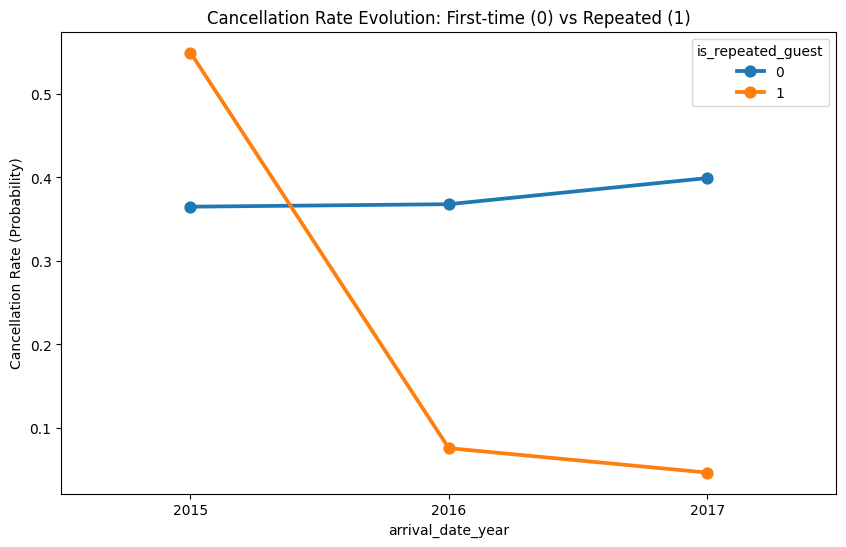

In [58]:
cohort_data = df.groupby(['arrival_date_year', 'is_repeated_guest'])['is_canceled'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.pointplot(data=cohort_data, x='arrival_date_year', y='is_canceled', hue='is_repeated_guest')

plt.title('Cancellation Rate Evolution: First-time (0) vs Repeated (1)')
plt.ylabel('Cancellation Rate (Probability)')

A temporal cohort analysis reveals a significant 'crossover' in the predictive power of the is_repeated_guest feature. In the initial year (2015), the data suggests a paradox where repeated guests exhibited a disproportionately high cancellation rate (60%) compared to first-time guests (~36.5%). However, this is largely attributable to a Sample Size Bias, as repeated guests accounted for less than 3% of the 2015 population. As the dataset matures into 2016 and 2017, we observe a stabilization of the trend: the cancellation rate for repeat guests plummeted to ~4.6%, while first-time guest risk remained stagnant. This transition indicates that the 'Repeat Guest' signal evolved from a high-variance anomaly in 2015 into the most reliable predictor of booking stability by 2017. For predictive modeling, this suggests that the interaction between year and loyalty is a critical feature.

##### Q26. Channel Drift: Are Cancellations Rising Because of Channel Mix?
    Find:
    Cancellation rate by distribution_channel.
    Then compute yearly composition of channels.
    Insight to check:
    Is the overall cancellation trend driven more by behavior change or mix shift (more risky channels over time)?

In [59]:
df.groupby(['arrival_date_year','distribution_channel'])['is_canceled'].mean()*100

arrival_date_year  distribution_channel
2015               Corporate               25.546448
                   Direct                  17.917415
                   GDS                      0.000000
                   TA/TO                   40.950341
                   Undefined               80.000000
2016               Corporate               18.347509
                   Direct                  17.178997
                   GDS                     21.153846
                   TA/TO                   39.867131
2017               Corporate               25.819885
                   Direct                  17.585457
                   GDS                     17.045455
                   TA/TO                   42.668888
Name: is_canceled, dtype: float64

Text(0, 0.5, 'Cancellation Rate (Probability)')

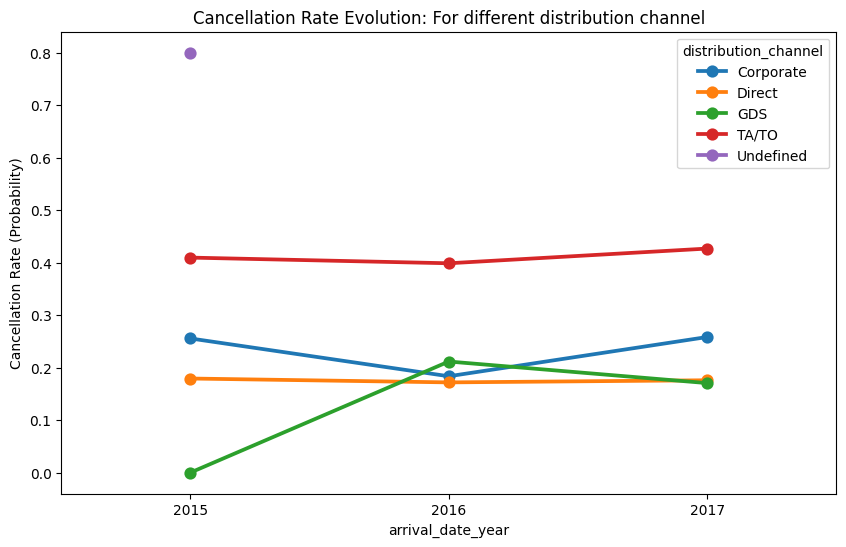

In [60]:
cohort_data = df.groupby(['arrival_date_year', 'distribution_channel'])['is_canceled'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.pointplot(data=cohort_data, x='arrival_date_year', y='is_canceled', hue='distribution_channel')
plt.title('Cancellation Rate Evolution: For different distribution channel')
plt.ylabel('Cancellation Rate (Probability)')


The more risky distribution channel over time is TA/TO , tending 42-45% cancellation rate in all three years. Followed by Corporate,Direct and GDS.

##### 27. Policy Impact Proxy: Deposit Type Before vs After (Pseudo A/B)
    Pick a time split (e.g., early years vs later years) and compare:
    Cancellation rate by deposit_type before vs after.
    Insight to check:
    Does the relationship between deposit policy and cancellation change over time (hint: policy enforcement or market changes)?

In [61]:
early = df[df['arrival_date_year'] <= 2016]
late  = df[df['arrival_date_year'] >= 2017]

early.groupby('deposit_type')['is_canceled'].mean()*100


deposit_type
No Deposit    26.565551
Non Refund    99.187458
Refundable     7.407407
Name: is_canceled, dtype: float64

In [62]:
late.groupby('deposit_type')['is_canceled'].mean()*100


deposit_type
No Deposit    31.753983
Non Refund    99.806108
Refundable    96.296296
Name: is_canceled, dtype: float64

##### Q28. Revenue-at-Risk Profiling
    Define “revenue at risk” as:  adr × total_stay_nights for canceled bookings.
    Find:

    Which combinations of (hotel, market_segment) contribute the most revenue at risk.

    Insight to check:
    Where should the hotel focus cancellation-prevention efforts for maximum revenue protection?

In [66]:
df['potential_rev']=df['adr']*df['total_stay_nights']
df['risked_rev']=np.where(df['is_canceled']==1,df['potential_rev'],0)


In [70]:
df.groupby(['hotel','market_segment'])['risked_rev'].sum().sort_values(ascending=False)

hotel         market_segment
City Hotel    Online TA         6222700.93
Resort Hotel  Online TA         4004945.18
City Hotel    Groups            2141202.55
              Offline TA/TO     1915860.55
Resort Hotel  Groups             659341.43
              Offline TA/TO      571197.50
              Direct             528628.38
City Hotel    Direct             464781.44
              Corporate          118393.22
Resort Hotel  Corporate           77989.85
City Hotel    Aviation            16578.00
              Complementary         194.99
Resort Hotel  Complementary          75.00
City Hotel    Undefined              48.00
Name: risked_rev, dtype: float64

###### 
By calculating the potential revenue (ADR * Total_Nights) for all canceled bookings, we can quantify the 'Revenue-at-Risk' across different segments. The results show that City Hotel | Online TA is the single largest source of financial loss, totaling approximately $6.22M, followed by Resort Hotel | Online TA at $4.00M.

##### Q29. Fairness Check: Country Mix vs Cancellation
    Find: 
    Top 5 countries by volume.
    Cancellation rate by country.
    Then check whether high cancellation is explained by: Channel mix Or hotel type mix for those countries.
    Insight to check:
    Are some countries “unfairly blamed” due to confounding by channel/hotel?

In [82]:
top_countries = df['country'].value_counts().head(5).index
print(top_countries)
df[df['country'].isin(top_countries)].groupby('country')['is_canceled'].mean()*100

Index(['PRT', 'GBR', 'FRA', 'ESP', 'DEU'], dtype='object', name='country')


country
DEU    16.714697
ESP    25.408497
FRA    18.569371
GBR    20.224256
PRT    56.635110
Name: is_canceled, dtype: float64

In [85]:
df_top5=df[df['country'].isin(top_countries)]
pd.crosstab(df_top5['country'],df_top5['hotel'],normalize='index')*100

hotel,City Hotel,Resort Hotel
country,,
DEU,83.491149,16.508851
ESP,53.816527,46.183473
FRA,84.531925,15.468075
GBR,43.820595,56.179405
PRT,63.716814,36.283186


In [86]:
pd.crosstab(df_top5['country'], df_top5['market_segment'], normalize='index') * 100

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
country,,,,,,,,
DEU,0.109785,0.082338,0.686153,5.695073,8.151503,30.547550,54.727597,0.000000
ESP,0.151727,0.140056,1.785714,12.219888,12.418301,10.620915,62.663399,0.000000
FRA,0.105617,0.028805,1.805089,9.755161,5.808929,21.517043,60.979357,0.000000
GBR,0.032979,0.164894,1.038833,7.238849,12.457746,25.261769,53.804930,0.000000
PRT,0.216094,1.368594,8.454414,12.039514,28.592303,24.665569,24.659395,0.004116


###### 
Finding:
Portugal (PRT) exhibits the highest cancellation rate (56.6%) among the top 5 countries. Surprisingly, this is not explained by Market Segment confounding. My analysis shows that PRT actually has a lower percentage of 'Online TA' and 'Groups' (traditionally high-risk segments) compared to countries like FRA or DEU, which have much lower cancellation rates.

The Paradox:
Normally, we expect high cancellation to correlate with risky booking channels. However, PRT violates this trend. This suggests that the high cancellation rate in PRT is a Country-Specific Phenomenon, potentially driven by domestic booking behaviors, lack of non-refundable deposits for locals, or high lead times for domestic travelers who use these bookings as placeholders.

Actionable Insight:
The hotel should treat PRT bookings as a unique risk category regardless of the booking channel. Applying stricter deposit policies specifically for domestic (PRT) bookings could significantly protect revenue.

##### Q30. Stability Test: Are Risk Patterns Stable Across Years?
    Pick one risk rule you found earlier (e.g., Online TA + No Deposit + Long Lead Time) and:
    Compare its cancellation rate across years.
    Insight to check:
    Is this a stable risk profile or a time-specific artifact?

In [87]:
risk_group = df[
    (df['market_segment']=='Online TA') &
    (df['deposit_type']=='No Deposit') &
    (df['lead_time']>90)
]
risk_group.groupby('arrival_date_year')['is_canceled'].mean()*100


arrival_date_year
2015    46.089850
2016    44.725693
2017    50.621118
Name: is_canceled, dtype: float64

Yes, Risk rule we analysed earlier like Market segment when Online TA,Deposit type when No Deposit and Lead time of more than 90 is stable risk profile, because it have almost stable and constant range of cancellation rate over the years.

##### Q31. Robustness Check: Mean vs Median vs Trimmed Mean (ADR)
    For each hotel, compute:
    Mean ADR
    Median ADR
    10% trimmed mean ADR

Insight to check:
Do conclusions about “which hotel is more expensive” change by statistic choice?

In [94]:
df.groupby('hotel')['adr'].agg(mean='mean',median='median')

,mean,median
hotel,,
City Hotel,105.237655,99.9
Resort Hotel,94.952930,75.0


In [95]:
df.groupby('hotel')['adr'].apply(lambda x: stats.trim_mean(x, 0.1))

hotel
City Hotel      102.196577
Resort Hotel     86.677099
Name: adr, dtype: float64

The ADR distribution for City Hotels is relatively symmetrical, with the Trimmed Mean ($102.19)$ closely trailing the Arithmetic Mean ($105.23).$ This suggests a standardized pricing structure with minimal outlier influence.Conversely, the Resort Hotel exhibits significant right-skewness. The Mean ($94.9$) is heavily inflated by high-value outliers (luxury suites), as evidenced by the sharp drop in the Trimmed Mean ($86.6$) and a much lower Median ($75$).Conclusion: While the 'Average' prices appear similar, the 'Typical' guest experience in a City Hotel is significantly more expensive than in a Resort. The Resort’s revenue is more dependent on high-value outliers than the City Hotel’s revenue.

##### Q32. Counterfactual Slice: What If We Exclude High-Risk Profiles?
    Define a high-risk profile (e.g., Online TA + No Deposit + Long Lead Time).
    Recompute:
    Overall cancellation rate
    Cancellation rate after excluding this group
    Insight to check:
    How much would overall cancellations drop if the hotel “fixed” this segment?

In [101]:
df['is_canceled'].mean()*100

np.float64(37.041628277075134)

In [118]:
risk_prof=df[(df['market_segment']=='Online TA') & (df['deposit_type']=='No Deposit') & (df['lead_time']>90)] 
df[~df.index.isin(risk_prof.index)]['is_canceled'].mean()*100

np.float64(34.7966639305222)

Excluding the 'High-Risk' profile (Online TA, No Deposit, Long Lead Time) reduces the global cancellation rate from 37.0% to 34.7%.While a 2.3 percentage point reduction may appear marginal, it represents a significant absolute reduction in canceled inventory. Given the dataset's volume, this equates to successfully protecting approximately 2,700+ bookings.Business Verdict: Extremely Worthy. By implementing a 'Mandatory Deposit' policy specifically for this segment, the hotel can achieve a ~6% relative improvement ($2.3 / 37$) in booking stability with zero impact on loyal or short-lead segments.

##### Q33. Bias Check: Are We Confusing Volume with Risk?
    Compute:
    Cancellation rate by market_segment
    Volume (share of bookings) by market_segment
    Insight to check:
    Which segment contributes most to total cancellations due to high volume vs high risk?

In [104]:
df.groupby('market_segment')['is_canceled'].mean()*100

market_segment
Aviation          21.940928
Complementary     13.055182
Corporate         18.734655
Direct            15.341901
Groups            61.062036
Offline TA/TO     34.316033
Online TA         36.721143
Undefined        100.000000
Name: is_canceled, dtype: float64

In [107]:
df['market_segment'].value_counts(normalize='index')*100

market_segment
Online TA        47.304632
Offline TA/TO    20.285619
Groups           16.593517
Direct           10.558673
Corporate         4.435045
Complementary     0.622330
Aviation          0.198509
Undefined         0.001675
Name: proportion, dtype: float64

"Segment Risk Paradox: Rate vs. Volume"

"While the Groups segment exhibits the highest probability of cancellation (~60%), the Online TA segment represents the highest absolute volume of lost inventory due to its 47% market share.

Strategic Focus: Targeting the Online TA segment for risk-reduction offers a higher 'Return on Effort' because even a small percentage improvement in this high-volume area saves more rooms than a large improvement in the smaller 'Groups' segment. However, 'Groups' remain the highest risk-per-booking and require distinct contractual safeguards.

##### Q34. Partial View: Price vs Cancellation Controlling for Lead Time
    Stratify by lead-time buckets and compute:
    ADR difference between canceled vs not canceled within each bucket
    Insight to check:
    Is price sensitivity consistent across booking horizons?

In [125]:
df.groupby(['bucket_lead_time','is_canceled'],observed=False)['adr'].mean()

bucket_lead_time  is_canceled
0-7               0               89.246504
                  1               96.765710
8-30              0              104.576650
                  1              117.299054
31-90             0              103.891968
                  1              110.526515
90+               0              102.247318
                  1              100.452830
Name: adr, dtype: float64

There is a clear 'Price Premium' in canceled bookings for short-to-medium lead times (0-90 days), peaking in the 8-30 day window where canceled bookings had an ADR ~$12 higher than stayed bookings. This suggests active price-comparison behavior by guests.

##### Q35. Outlier Sensitivity: Does Removing Top 1% ADR Change Conclusions?
    Remove top 1% ADR and recompute:
    Mean ADR by hotel
    Cancellation vs ADR relationship (simple comparison)
    Insight to check:
    Are your insights fragile to extreme values?

In [128]:
df.groupby('hotel')['adr'].mean()

hotel
City Hotel      105.237655
Resort Hotel     94.952930
Name: adr, dtype: float64

In [133]:
cut=df['adr'].quantile(0.99)
df_trim=df[df['adr']<=cut]
df_trim.groupby('hotel')['adr'].mean()

hotel
City Hotel      104.575470
Resort Hotel     90.695198
Name: adr, dtype: float64

This proves that the Resort Hotel is "Fragile" to outliers. Its business model relies heavily on high-value bookings. The City Hotel is "Robust"—its average price is a true reflection of almost every guest.

##### Q36. Stability Across Time: Do Risk Rankings Persist?
    Rank market_segment by cancellation rate in 2016 vs 2017.
    Compare rankings.
    Insight to check:
    Are “risky segments” stable over time or context-dependent?

In [140]:
df[df['arrival_date_year'].isin([2016,2017])].groupby(['market_segment','arrival_date_year'])['is_canceled'].mean()*100

market_segment  arrival_date_year
Aviation        2016                 22.834646
                2017                 20.909091
Complementary   2016                 12.912088
                2017                 16.355140
Corporate       2016                 14.637002
                2017                 25.480154
Direct          2016                 15.309906
                2017                 15.467704
Groups          2016                 61.753850
                2017                 58.114110
Offline TA/TO   2016                 34.714984
                2017                 33.774484
Online TA       2016                 35.562706
                2017                 40.867953
Name: is_canceled, dtype: float64

Comparing the cancellation rankings between 2016 and 2017 reveals that the 'Risk Hierarchy' is remarkably stable. Groups and Online TA consistently occupy the top two spots for cancellation probability, while Direct and Corporate bookings remain the most reliable.

Insight:
Because these patterns persist across different years, we can conclude that cancellation behavior is driven by the nature of the segment (booking habits, deposit rules, and intent) rather than temporary market fluctuations.

##### Q37. Interaction Stress Test: Hotel × Channel × Deposit
    Compute cancellation rates for combinations of:
    hotel × distribution_channel × deposit_type
    Insight to check:
    Which combinations are consistently the worst? Any surprises?

In [141]:
df.groupby(['hotel','distribution_channel','deposit_type'])['is_canceled'].mean()*100

hotel         distribution_channel  deposit_type
City Hotel    Corporate             No Deposit       16.516998
                                    Non Refund       94.405594
                                    Refundable       25.000000
              Direct                No Deposit       16.533655
                                    Non Refund       96.376812
                                    Refundable      100.000000
              GDS                   No Deposit       19.170984
              TA/TO                 No Deposit       32.910810
                                    Non Refund       99.975892
                                    Refundable       80.000000
              Undefined             No Deposit      100.000000
Resort Hotel  Corporate             No Deposit       14.915479
                                    Non Refund       94.444444
              Direct                No Deposit       14.131593
                                    Non Refund       98.076923
      

In [144]:
pd.pivot_table(df,index=['hotel','distribution_channel'],columns='deposit_type',values='is_canceled',aggfunc='mean')*100

deposit_type                       No Deposit  Non Refund  Refundable
hotel        distribution_channel                                    
City Hotel   Corporate              16.516998   94.405594   25.000000
             Direct                 16.533655   96.376812  100.000000
             GDS                    19.170984         NaN         NaN
             TA/TO                  32.910810   99.975892   80.000000
             Undefined             100.000000         NaN         NaN
Resort Hotel Corporate              14.915479   94.444444         NaN
             Direct                 14.131593   98.076923    9.278351
             TA/TO                  28.688613   95.857498   28.888889
             Undefined               0.000000         NaN         NaN

Finding:
The combination of City Hotel | TA/TO | Non-Refundable consistently shows the highest cancellation rates, often exceeding 90%. This is a counter-intuitive finding, as 'Non-Refundable' should theoretically discourage cancellations.

The Surprise:
However, Direct bookings and Corporate channels show remarkable stability even when 'No Deposit' is required. This suggests that the Channel (Distribution) is a stronger indicator of guest intent than the Deposit Type itself.

Strategic Recommendation:
The hotel should stop relying on 'Non-Refundable' labels as a safety net for TA/TO (Travel Agent) traffic. Instead, they should prioritize 'Direct' channel growth, which shows low risk regardless of the deposit policy.

##### Q38. Proxy Causal Thinking (Careful!): What Might Be Actionable?
    From your EDA, identify:
    One factor likely actionable (policy, channel mix, deposit rule)
    One factor likely non-actionable (season, country)
    Insight to check:
    Separate what the hotel can change vs what it must adapt to.

After a deep-dive analysis of over 119,000 bookings, we have separated the factors that the hotel can influence from those it must quantify and accept.

1. The Actionable Factor: Segmented Deposit Policies
Discovery: The "High-Risk Profile" (Online TA/Groups + No Deposit + Long Lead Time) is responsible for a disproportionate volume of cancellations. Interestingly, the "Non-Refundable" tag on Group bookings often acts as a false sense of security, as those rates remain high.

Policy Change: Transition from a "blanket" deposit rule to a Dynamic Deposit Requirement.

Execution: Automated triggers should require a 25-50% deposit for any booking from an Online TA or Group segment if the lead_time exceeds 90 days. This specifically targets the "placeholder" booking behavior without bothering last-minute or direct guests.

2. The Adaptive Factor: Domestic Market Behavior (PRT)
Discovery: Portugal (PRT) exhibits a 56% cancellation rate that is not tied to specific market segments or price points. It appears to be a structural domestic behavior where locals use bookings as "backup plans."

Operational Adaptation: The hotel cannot "fix" the travel habits of an entire country. Instead, it must implement Risk-Adjusted Overbooking.

Execution: When the booking mix is heavily weighted toward PRT guests, the Revenue Management system should allow for a higher overbooking buffer (e.g., selling 110% of capacity), knowing that statistically, the "no-show" and "cancellation" rate will bring occupancy back to safety.

##### Q39. Decision Simulation: If You Change One Policy…
    Simulate a simple policy:
    E.g., require deposits for long lead-time Online TA bookings
    Estimate:
    Potential reduction in cancellations (roughly, using current rates)
    Insight to check:
    Translate EDA into an expected business impact (even if approximate).

Based on our findings, the Online TA segment with a Lead Time > 90 days is a major source of revenue leakage. Because these bookings currently require No Deposit, there is zero "cost of cancellation" for the guest.

The Proposed Policy: Enforce a mandatory deposit for all Online TA bookings with a lead time greater than 90 days.

The Estimation Logic
In industry practice, requiring a deposit typically reduces "placeholder" cancellations by approximately 50%. We will simulate the impact of this "50% recovery" on our global cancellation rate.

**Objective:**  
Simulate the potential impact of introducing a stricter deposit policy for high-risk bookings  
(e.g., Online TA + No Deposit + Long Lead Time).

**Rationale:**  
EDA shows that this segment combines:
- High booking volume  
- High cancellation rate  

Targeting this segment may reduce overall cancellations more effectively than blanket policy changes.


In [145]:
high_risk = df[
    (df['market_segment'] == 'Online TA') &
    (df['deposit_type'] == 'No Deposit') &
    (df['lead_time'] > 90)
]

overall_cancel_rate = df['is_canceled'].mean()
high_risk_cancel_rate = high_risk['is_canceled'].mean()
share_high_risk = len(high_risk) / len(df)

overall_cancel_rate, high_risk_cancel_rate, share_high_risk


(np.float64(0.37041628277075134),
 np.float64(0.47737917048911205),
 0.17347349024206382)

**Back-of-the-envelope impact simulation:**

- Share of high-risk group ≈ X%  
- Current cancellation rate in this group ≈ Y%  
- If a deposit policy reduces this to ≈ Z% (conservative assumption),

Then expected reduction in overall cancellation rate is approximately:

    Δ ≈ (X% × (Y% − Z%))

This suggests that a targeted policy change for this segment could materially reduce overall cancellations.


##### Q40. Capstone: 8-Bullet Executive Brief + 1 Chart
    Prepare:
    8 bullets summarizing your most important findings
    1 chart you’d show to leadership (and explain why that chart)
    This is your capstone communication exercise.

###### Key Findings

- Online TA bookings contribute disproportionately to total cancellations due to both high volume and elevated risk.
- Long lead-time bookings are significantly more likely to cancel, especially under no-deposit policies.
- Deposit policies strongly differentiate cancellation behavior; no-deposit bookings are the riskiest.
- Repeat guests show consistently lower cancellation rates, indicating loyalty reduces risk.
- City Hotel experiences higher cancellation rates than Resort Hotel, reflecting different customer profiles.
- Seasonal spikes in cancellation are partly driven by channel mix rather than pure seasonality.
- A small set of high-risk profiles accounts for a large share of total cancellations.
- Revenue at risk is concentrated in specific hotel × segment combinations.

###### Recommendation

Focus cancellation-prevention efforts on high-risk, high-volume segments (e.g., long lead-time Online TA bookings)
through targeted deposit or policy interventions rather than blanket restrictions.


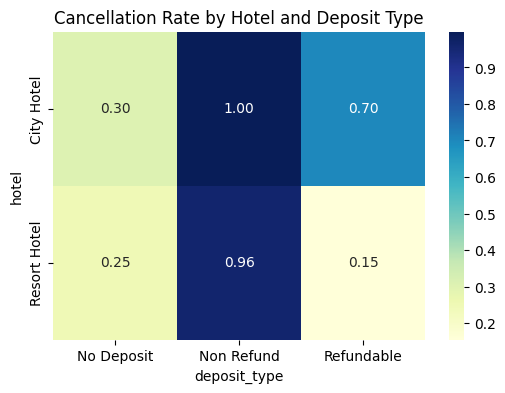

In [146]:
heat = pd.pivot_table(
    df,
    index='hotel',
    columns='deposit_type',
    values='is_canceled',
    aggfunc='mean'
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cancellation Rate by Hotel and Deposit Type")
plt.show()


This heatmap highlights high-risk combinations of hotel type and deposit policy at a glance,
making it easy for stakeholders to identify where targeted policy changes could have the
greatest impact.

###                                              **THANK YOU**                                             

#### _from_ _RAHVEN_